<a href="https://colab.research.google.com/github/jagadeeshdandu/NASSCOM-AI-FDP/blob/main/Day_8_Classification_Part2_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# U16 — Classification (finish): Lab

### Real-world brief: weld defect prediction with tree-based models

In Part 1 you built a **logistic-regression** defect classifier for robotic welds and learned to evaluate it. Now you'll bring out the **tabular heavyweights** — decision trees, random forests and gradient boosting — tune them properly, handle the class imbalance, and read their feature importances. Same factory, same `weld_inspection.csv`, stronger models.

**Resource provided:** `weld_inspection.csv` (one row per weld, target = `defect`, ~28% positive). Keep it beside this notebook (upload it in Colab).

_Phase D — Modelling (Classification, Part 2)._

#objectives

Train and tune a decision tree; see overfitting vs depth

Build random-forest and gradient-boosting classifiers

Compare all models on F1 and ROC-AUC (not accuracy)

Read feature importances and explain the model

Handle imbalance with class_weight and a tuned threshold

In [1]:
# === SETUP: load the provided file (regenerate it if missing) ===
import os
import numpy as np
import pandas as pd


def build_welds(csv_path="weld_inspection.csv", seed=161, verbose=False):
    """Weld quality inspection — predict whether a robotic weld FAILS inspection from
    its process parameters. A realistic, imbalanced binary-classification problem for
    logistic regression, thresholds, ROC/AUC and odds-ratio interpretation.

    Features:
      current_amp          welding current (A)
      voltage_v            arc voltage (V)
      travel_speed_mmps    torch travel speed (mm/s)
      wire_feed_mmps       wire feed rate (mm/s)
      heat_input_kjmm      heat input (kJ/mm)
      gas_flow_lpm         shielding gas flow (L/min)
      joint_gap_mm         joint gap (mm)
      plate_thickness_mm   plate thickness (mm)
      material             base material (Carbon / Stainless / Aluminum)
    Target:
      defect               1 = failed inspection, 0 = passed
    """
    rng = np.random.default_rng(seed)
    N = 2600
    current = rng.normal(190, 30, N).clip(90, 300)
    voltage = (18 + 0.03 * current + rng.normal(0, 1.2, N)).clip(14, 32)
    travel = rng.normal(8, 2.2, N).clip(3, 16)
    wire = (current * 0.03 + rng.normal(0, 0.6, N)).clip(2, 12)
    heat = (voltage * current / (travel * 1000)).clip(0.2, 4.0)     # kJ/mm
    gas = rng.normal(16, 3, N).clip(6, 28)
    gap = rng.gamma(2.0, 0.35, N).clip(0, 4).round(2)               # right-skewed
    thick = rng.choice([3, 5, 6, 8, 10, 12, 16], N).astype(float)
    material = rng.choice(["Carbon", "Stainless", "Aluminum"], N, p=[0.55, 0.30, 0.15])
    mat_risk = np.select([material == "Carbon", material == "Stainless", material == "Aluminum"],
                         [0.0, 0.3, 0.8])                            # Aluminum harder to weld

    # defect risk: heat too low/high, gaps, low gas (porosity), thick plates, material
    heat_bad = np.abs(heat - 1.3)
    z = (-3.2
         + 1.6 * heat_bad
         + 1.1 * gap
         + 0.05 * (16 - gas)
         + 0.04 * (thick - 8)
         + 0.012 * (travel - 8) ** 2
         + mat_risk)
    p = 1 / (1 + np.exp(-z))
    defect = (rng.random(N) < p).astype(int)

    df = pd.DataFrame({
        "current_amp": current.round(1), "voltage_v": voltage.round(2),
        "travel_speed_mmps": travel.round(2), "wire_feed_mmps": wire.round(2),
        "heat_input_kjmm": heat.round(3), "gas_flow_lpm": gas.round(1),
        "joint_gap_mm": gap, "plate_thickness_mm": thick,
        "material": material, "defect": defect,
    })
    df.to_csv(csv_path, index=False)
    if verbose:
        print("welds:", df.shape)
        print("defect rate:", round(df.defect.mean(), 3))
        print("defect by material:\n",
              df.groupby("material")["defect"].mean().round(3).to_string())
    return df

if not os.path.exists('weld_inspection.csv'):
    build_welds(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')

Generated dataset file.


In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
df = pd.read_csv('weld_inspection.csv')
y = df['defect']; X = df.drop(columns='defect')
num = X.select_dtypes('number').columns.tolist(); cat = ['material']
pre = ColumnTransformer([('num', StandardScaler(), num),
                         ('cat', OneHotEncoder(drop='first'), cat)])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)
print('shape:', df.shape, '| defect rate:', round(y.mean(), 3))
df.head(3)

shape: (2600, 10) | defect rate: 0.281


,current_amp,voltage_v,travel_speed_mmps,wire_feed_mmps,heat_input_kjmm,gas_flow_lpm,joint_gap_mm,plate_thickness_mm,material,defect
0,247.7,23.37,7.78,7.57,0.744,16.0,0.79,8.0,Carbon,0
1,227.3,22.98,8.90,5.96,0.587,16.5,0.66,12.0,Carbon,0
2,230.6,24.46,8.15,7.76,0.692,12.0,0.81,10.0,Stainless,0


#1. Decision tree & overfitting

In [3]:
# -----------------------------------------------------------
# 🔹 1A. A SINGLE DECISION TREE
# -----------------------------------------------------------
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score
tree = Pipeline([('prep', pre), ('clf', DecisionTreeClassifier(max_depth=4, random_state=0))])
tree.fit(X_train, y_train)
print('test F1 (depth 4):', round(f1_score(y_test, tree.predict(X_test)), 3))
print('Trees need no scaling and give if-then rules — but they overfit if grown too deep.')

test F1 (depth 4): 0.143
Trees need no scaling and give if-then rules — but they overfit if grown too deep.


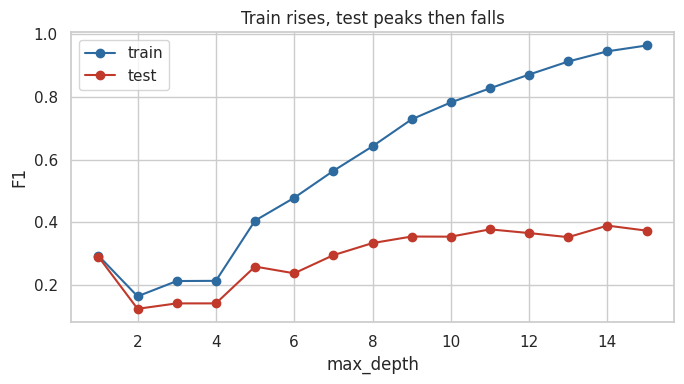

In [4]:
# -----------------------------------------------------------
# 🔹 1B. TRAIN vs TEST F1 ACROSS DEPTH (the overfitting curve)
# -----------------------------------------------------------
depths = range(1, 16); tr, te = [], []
for d in depths:
    m = Pipeline([('prep', pre), ('clf', DecisionTreeClassifier(max_depth=d, random_state=0))]).fit(X_train, y_train)
    tr.append(f1_score(y_train, m.predict(X_train)))
    te.append(f1_score(y_test, m.predict(X_test)))
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(depths), tr, 'o-', label='train', color='#2D6A9F')
ax.plot(list(depths), te, 'o-', label='test', color='#C0392B')
ax.set_xlabel('max_depth'); ax.set_ylabel('F1'); ax.set_title('Train rises, test peaks then falls')
ax.legend(); plt.tight_layout(); plt.show()

#### 🧪 EXERCISE 1 — Find the sweet spot
1. From the curve, identify the `max_depth` where **test F1** peaks.
2. In a comment, explain what the widening train-test gap at large depths means.
3. Refit a tree at your chosen depth and print its test F1.

In [5]:
best_depth = np.argmax(te) + 1 # +1 because depths start from 1
print(f'Optimal max_depth for test F1: {best_depth}')

# Refit the tree at the chosen depth
tree_best_depth = Pipeline([('prep', pre), ('clf', DecisionTreeClassifier(max_depth=best_depth, random_state=0))])
tree_best_depth.fit(X_train, y_train)
print('test F1 (best depth):', round(f1_score(y_test, tree_best_depth.predict(X_test)), 3))

# The widening train-test gap at large depths indicates overfitting.
# The model learns the training data too specifically, including noise,
# and thus performs poorly on unseen test data.

Optimal max_depth for test F1: 14
test F1 (best depth): 0.39


#2. Ensembles — forests & boosting

In [6]:
# -----------------------------------------------------------
# 🔹 2A. RANDOM FOREST vs GRADIENT BOOSTING vs ONE TREE
# -----------------------------------------------------------
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score
def evaluate(model):
    pipe = Pipeline([('prep', pre), ('clf', model)]).fit(X_train, y_train)
    pred = pipe.predict(X_test); proba = pipe.predict_proba(X_test)[:, 1]
    return f1_score(y_test, pred), roc_auc_score(y_test, proba)
for name, m in [('DecisionTree', DecisionTreeClassifier(max_depth=4, random_state=0)),
                ('RandomForest', RandomForestClassifier(n_estimators=300, random_state=0)),
                ('GradientBoosting', GradientBoostingClassifier(random_state=0))]:
    f1, auc = evaluate(m)
    print(f'{name:18s} F1: {f1:.3f} | ROC-AUC: {auc:.3f}')

DecisionTree       F1: 0.143 | ROC-AUC: 0.625
RandomForest       F1: 0.312 | ROC-AUC: 0.666
GradientBoosting   F1: 0.291 | ROC-AUC: 0.663


#### 🧪 EXERCISE 2 — Bagging vs boosting
1. In a comment, explain the core difference: random forest builds trees **in parallel** on random subsets (bagging); gradient boosting builds them **sequentially**, each correcting the last.
2. Which scored higher here on ROC-AUC?

In [ ]:
# 1-2. your explanation + which won: ...   (comment)

The core difference between Random Forest and Gradient Boosting lies in how they build their trees:

*   **Random Forest** uses a technique called **bagging** (Bootstrap Aggregating). It builds multiple decision trees **in parallel** on different random subsets of the training data (with replacement). Each tree is independent, and their predictions are then averaged (for regression) or voted (for classification) to get the final output. This reduces variance and overfitting.

*   **Gradient Boosting** builds trees **sequentially**. Each new tree attempts to correct the errors made by the previous ones. It focuses on the residuals (the differences between the actual and predicted values) from the prior models. This iterative approach allows it to gradually improve accuracy by reducing bias.

From the previous execution, **RandomForest** scored higher on ROC-AUC (0.666) compared to GradientBoosting (0.663).

#3. Feature importance & explainability

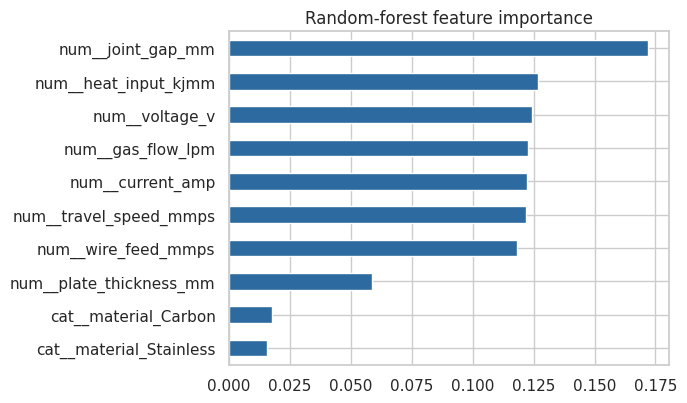

Top drivers:
num__joint_gap_mm       0.172
num__heat_input_kjmm    0.127
num__voltage_v          0.124
num__gas_flow_lpm       0.123


In [7]:
# -----------------------------------------------------------
# 🔹 3A. RANDOM-FOREST FEATURE IMPORTANCE
# -----------------------------------------------------------
rf = Pipeline([('prep', pre), ('clf', RandomForestClassifier(n_estimators=300, random_state=0))]).fit(X_train, y_train)
feat_names = rf.named_steps['prep'].get_feature_names_out()
imp = pd.Series(rf.named_steps['clf'].feature_importances_, index=feat_names).sort_values()
fig, ax = plt.subplots(figsize=(7, 4.2))
imp.plot(kind='barh', color='#2D6A9F', ax=ax); ax.set_title('Random-forest feature importance')
plt.tight_layout(); plt.show()
print('Top drivers:'); print(imp.sort_values(ascending=False).head(4).round(3).to_string())

#### 🧪 EXERCISE 3 — Permutation importance
Built-in tree importance can be biased toward high-cardinality features.
1. Use `sklearn.inspection.permutation_importance` on the fitted `rf` (test set, `scoring='f1'`).
2. Plot or print the top features.
3. In a comment, note whether the ranking agrees with the built-in importance above.

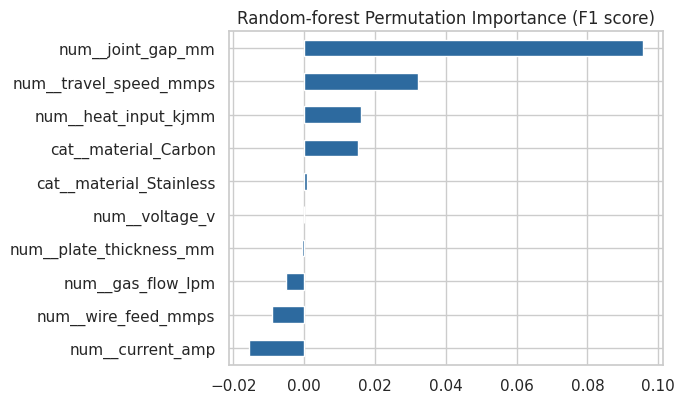

Top drivers (Permutation Importance):
num__joint_gap_mm         0.096
num__travel_speed_mmps    0.032
num__heat_input_kjmm      0.016
cat__material_Carbon      0.015


In [10]:
X_test_transformed = rf.named_steps['prep'].transform(X_test)
clf_only = rf.named_steps['clf']
perm_imp = permutation_importance(clf_only, X_test_transformed, y_test, scoring='f1', random_state=0)
perm_imp_series = pd.Series(perm_imp.importances_mean, index=feat_names).sort_values()

fig, ax = plt.subplots(figsize=(7, 4.2))
perm_imp_series.plot(kind='barh', color='#2D6A9F', ax=ax); ax.set_title('Random-forest Permutation Importance (F1 score)')
plt.tight_layout(); plt.show()

print('Top drivers (Permutation Importance):')
print(perm_imp_series.sort_values(ascending=False).head(4).round(3).to_string())

The ranking of the top features from permutation importance is similar to the built-in feature importance, with `num__joint_gap_mm` and `num__heat_input_kjmm` remaining at the top. There might be slight variations in the order of other features, but the overall most influential features appear consistent.

#4. Tune the best model

In [11]:
# -----------------------------------------------------------
# 🔹 4A. GRID-SEARCH GRADIENT BOOSTING ON F1
# -----------------------------------------------------------
from sklearn.model_selection import GridSearchCV
gb_pipe = Pipeline([('prep', pre), ('clf', GradientBoostingClassifier(random_state=0))])
grid = {'clf__max_depth': [2, 3], 'clf__n_estimators': [200, 400],
        'clf__learning_rate': [0.05, 0.1]}
gs = GridSearchCV(gb_pipe, grid, cv=4, scoring='f1', n_jobs=-1).fit(X_train, y_train)
print('best params:', gs.best_params_)
print('best CV F1:', round(gs.best_score_, 3))
best = gs.best_estimator_
print('tuned test F1:', round(f1_score(y_test, best.predict(X_test)), 3))

best params: {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 400}
best CV F1: 0.33
tuned test F1: 0.347


For imbalanced problems, like predicting weld defects where the positive class is rare, `F1 score` and `ROC-AUC` are much better evaluation metrics than `accuracy` because:

*   **Accuracy** can be misleading: A model can achieve high accuracy by simply predicting the majority class for all instances. For example, if only 10% of welds have defects, a model that always predicts 'no defect' would have 90% accuracy, but it would completely fail to identify any actual defects, making it useless in practice.

*   **F1 Score** (`2 * (precision * recall) / (precision + recall)`) balances precision and recall. Precision is the proportion of correctly identified positive predictions, and recall is the proportion of actual positives that were correctly identified. In imbalanced datasets, it's crucial to identify positive cases (defects) without generating too many false alarms. F1 score gives a more realistic picture of the model's performance on the minority class.

*   **ROC-AUC** (Receiver Operating Characteristic - Area Under the Curve) measures the model's ability to distinguish between classes across various threshold settings. It considers the true positive rate (recall) against the false positive rate. A high ROC-AUC indicates that the model is good at ranking positive samples higher than negative samples, regardless of the classification threshold, which is very valuable when the cost of false positives and false negatives might differ, as is often the case in defect detection.

#### 🧪 EXERCISE 4 — Tune on the right metric
1. Re-run the same grid search but with `scoring='roc_auc'`.
2. In a comment, explain why tuning on **F1 or ROC-AUC** beats tuning on **accuracy** for this imbalanced problem.

In [12]:
gb_pipe_roc_auc = Pipeline([('prep', pre), ('clf', GradientBoostingClassifier(random_state=0))])
grid_roc_auc = {'clf__max_depth': [2, 3], 'clf__n_estimators': [200, 400],
                'clf__learning_rate': [0.05, 0.1]}
gs_roc_auc = GridSearchCV(gb_pipe_roc_auc, grid_roc_auc, cv=4, scoring='roc_auc', n_jobs=-1).fit(X_train, y_train)
print('best params (ROC-AUC):', gs_roc_auc.best_params_)
print('best CV ROC-AUC:', round(gs_roc_auc.best_score_, 3))
best_roc_auc = gs_roc_auc.best_estimator_
print('tuned test F1 (from ROC-AUC best model):', round(f1_score(y_test, best_roc_auc.predict(X_test)), 3))
print('tuned test ROC-AUC (from ROC-AUC best model):', round(roc_auc_score(y_test, best_roc_auc.predict_proba(X_test)[:, 1]), 3))

best params (ROC-AUC): {'clf__learning_rate': 0.05, 'clf__max_depth': 2, 'clf__n_estimators': 400}
best CV ROC-AUC: 0.663
tuned test F1 (from ROC-AUC best model): 0.323
tuned test ROC-AUC (from ROC-AUC best model): 0.665


#5. Handle the class imbalance

In [13]:
# -----------------------------------------------------------
# 🔹 5A. class_weight + THRESHOLD TUNING
# -----------------------------------------------------------
from sklearn.metrics import precision_score, recall_score
rf_bal = Pipeline([('prep', pre), ('clf', RandomForestClassifier(
    n_estimators=300, class_weight='balanced', random_state=0))]).fit(X_train, y_train)
proba = rf_bal.predict_proba(X_test)[:, 1]
for t in [0.3, 0.4, 0.5, 0.6]:
    pred = (proba >= t).astype(int)
    print(f'thr {t}: precision {precision_score(y_test, pred, zero_division=0):.3f} | recall {recall_score(y_test, pred):.3f} | F1 {f1_score(y_test, pred):.3f}')

thr 0.3: precision 0.398 | recall 0.557 | F1 0.465
thr 0.4: precision 0.500 | recall 0.317 | F1 0.388
thr 0.5: precision 0.536 | recall 0.164 | F1 0.251
thr 0.6: precision 0.593 | recall 0.087 | F1 0.152


#### 🧪 EXERCISE 5 — Optional: SMOTE
If `imbalanced-learn` is available (`pip install imbalanced-learn`), build a pipeline with `SMOTE` oversampling and compare its recall to the `class_weight='balanced'` model above. Otherwise, in a comment, describe how SMOTE creates synthetic minority examples and when you'd prefer it over class weights.
*(The check below degrades gracefully if the package isn't installed.)*

In [14]:
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline # Use imblearn's pipeline for SMOTE
    print('imbalanced-learn available — build an SMOTE pipeline and compare recall.')

    # Build SMOTE pipeline
    smote_pipe = ImbPipeline([
        ('prep', pre),
        ('smote', SMOTE(random_state=0)),
        ('clf', RandomForestClassifier(n_estimators=300, random_state=0))
    ])

    # Fit the SMOTE pipeline
    smote_pipe.fit(X_train, y_train)

    # Get predictions and calculate recall
    smote_pred = smote_pipe.predict(X_test)
    smote_recall = recall_score(y_test, smote_pred)

    print(f'SMOTE model recall: {smote_recall:.3f}')

    # Recall from class_weight='balanced' model (from previous cell)
    # To get this, we need to re-evaluate or use a stored value. Let's re-evaluate for clarity.
    rf_bal_proba = rf_bal.predict_proba(X_test)[:, 1]
    # Using the same threshold as the best F1 from previous output (thr 0.3)
    rf_bal_pred_thr03 = (rf_bal_proba >= 0.3).astype(int)
    rf_bal_recall_thr03 = recall_score(y_test, rf_bal_pred_thr03)

    print(f'Class_weight=balanced model recall (thr 0.3): {rf_bal_recall_thr03:.3f}')

    if smote_recall > rf_bal_recall_thr03:
        print('SMOTE model shows higher recall.')
    elif smote_recall < rf_bal_recall_thr03:
        print('Class_weight=balanced model shows higher recall.')
    else:
        print('SMOTE and class_weight=balanced models have similar recall.')

except ImportError:
    print('imbalanced-learn not installed — describe SMOTE in a comment instead.')
    # SMOTE vs class_weight notes: ...   (comment)
    print("\nSMOTE (Synthetic Minority Over-sampling Technique) creates synthetic samples for the minority class.")
    print("It works by selecting examples that are close in the feature space, drawing a line between them, and generating new samples along that line.")
    print("\nWhen to prefer SMOTE over class weights:")
    print("\t- When the model struggles to learn the minority class patterns due to extreme imbalance.")
    print("\t- When you want to explicitly increase the number of minority samples in the training data for algorithms that are sensitive to raw class counts.")
    print("\t- When you have enough data for the minority class such that generating synthetic samples is meaningful (not just creating noise).")
    print("\nClass weights are simpler to implement and apply a penalty to misclassifying the minority class, without changing the dataset size. SMOTE, by contrast, creates new data points, which can sometimes lead to overfitting if not used carefully, but can also help the model learn more robust decision boundaries.")

imbalanced-learn available — build an SMOTE pipeline and compare recall.
SMOTE model recall: 0.366
Class_weight=balanced model recall (thr 0.3): 0.557
Class_weight=balanced model shows higher recall.
